In [1]:
import zipfile
import datetime
import string
import math
import os

import tqdm
import matplotlib.pyplot as plt
import tensorflow as tf
import sklearn.model_selection

import keras_ocr
import tensorflow as tf 
from utils import get_text_generator

2025-03-19 15:21:16.907377: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-19 15:21:16.938659: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-19 15:21:17.371338: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
## Generating synthetic data
assert tf.test.is_gpu_available(), 'No GPU is available.'

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


2025-03-19 15:21:20.252999: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-03-19 15:21:20.271562: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-03-19 15:21:20.271706: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [3]:
data_dir = '.'
alphabet = string.digits + string.ascii_letters + '+-×±Φφ. '
fonts = keras_ocr.data_generation.get_fonts(
    alphabet=alphabet,
    cache_dir=data_dir
)

backgrounds = keras_ocr.data_generation.get_backgrounds(cache_dir=data_dir)

Looking for ./fonts.zip


Filtering fonts.: 100%|██████████| 2746/2746 [00:04<00:00, 643.90it/s]


Looking for ./backgrounds.zip


In [4]:
len(fonts)

328

In [5]:

myfonts = [
    './myfonts/fangsong_GB2312.ttf', 
    './myfonts/GenShinGothic-Medium.ttf', 
    './myfonts/GenShinGothic-Monospace-Normal.ttf', 
    './myfonts/GenShinGothic-Normal.ttf', 
    './myfonts/GenShinGothic-P-Normal.ttf', 
    './myfonts/GenShinGothic-Regular.ttf', 
    './myfonts/kaiti_GB2312.ttf', 
    './myfonts/msyh.ttf', 
    './myfonts/simhei.ttf', 
    './myfonts/songti.ttf'
]
for myfont in myfonts:
    fonts.append(myfont)

mybackgrounds = [
    './mybackgrounds/bg1.jpg',
    './mybackgrounds/bg2.jpg',
    './mybackgrounds/bg3.jpg',
    './mybackgrounds/bg4.jpg',
    './mybackgrounds/bg5.jpg',
    './mybackgrounds/bg6.jpg',
    './mybackgrounds/bg7.jpg',
    './mybackgrounds/bg8.jpg',
    './mybackgrounds/bg9.jpg',
    './mybackgrounds/bg10.jpg',
]
for mybackground in mybackgrounds:
    backgrounds.append(mybackground)

In [6]:
fonts

['./fonts/cousine/Cousine-Italic.ttf',
 './fonts/cousine/Cousine-BoldItalic.ttf',
 './fonts/cousine/Cousine-Regular.ttf',
 './fonts/cousine/Cousine-Bold.ttf',
 './fonts/ubuntu/Ubuntu-LightItalic.ttf',
 './fonts/ubuntu/Ubuntu-Light.ttf',
 './fonts/ubuntu/Ubuntu-MediumItalic.ttf',
 './fonts/ubuntu/Ubuntu-Regular.ttf',
 './fonts/ubuntu/Ubuntu-Italic.ttf',
 './fonts/ubuntu/Ubuntu-Bold.ttf',
 './fonts/ubuntu/Ubuntu-BoldItalic.ttf',
 './fonts/ubuntu/Ubuntu-Medium.ttf',
 './fonts/firacode/FiraCode[wght].ttf',
 './fonts/comfortaa/Comfortaa[wght].ttf',
 './fonts/seoulnamsanvertical/SeoulNamsanVertical-Regular.ttf',
 './fonts/alegreyasc/AlegreyaSC-Regular.ttf',
 './fonts/alegreyasc/AlegreyaSC-ExtraBold.ttf',
 './fonts/alegreyasc/AlegreyaSC-ExtraBoldItalic.ttf',
 './fonts/alegreyasc/AlegreyaSC-Italic.ttf',
 './fonts/alegreyasc/AlegreyaSC-BoldItalic.ttf',
 './fonts/alegreyasc/AlegreyaSC-Black.ttf',
 './fonts/alegreyasc/AlegreyaSC-BlackItalic.ttf',
 './fonts/alegreyasc/AlegreyaSC-Medium.ttf',
 './f

In [7]:
# text_generator = keras_ocr.data_generation.get_text_generator(alphabet=alphabet)
text_generator = get_text_generator(alphabet=alphabet)
print('The first generated text is:', next(text_generator))

The first generated text is: rwc63×7.46-80zgny


In [8]:
def get_train_val_test_split(arr):
    train, valtest = sklearn.model_selection.train_test_split(arr, train_size=0.8, random_state=42)
    val, test = sklearn.model_selection.train_test_split(valtest, train_size=0.5, random_state=42)
    return train, val, test

In [9]:
background_splits = get_train_val_test_split(backgrounds)
font_splits = get_train_val_test_split(fonts)

In [10]:
image_generators = [
    keras_ocr.data_generation.get_image_generator(
        height=640,
        width=640,
        text_generator=text_generator,
        font_groups={
            alphabet: current_fonts
        },
        backgrounds=current_backgrounds,
        font_size=(60, 120),
        margin=50,
        rotationX=(-0.05, 0.05),
        rotationY=(-0.05, 0.05),
        rotationZ=(-15, 15)
    )  for current_fonts, current_backgrounds in zip(
        font_splits,
        background_splits
    )
]

The first generated validation image (below) contains: Φ6
6


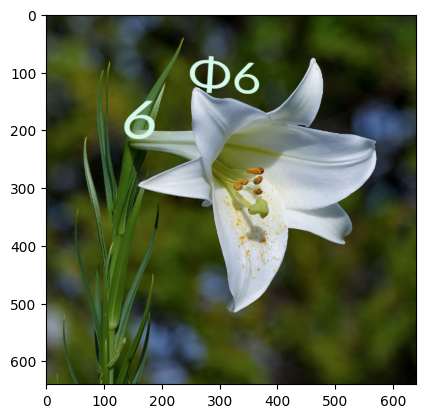

In [11]:
image, lines = next(image_generators[1])
text = keras_ocr.data_generation.convert_lines_to_paragraph(lines)
print('The first generated validation image (below) contains:', text)
plt.imshow(image)

In [12]:
detector = keras_ocr.detection.Detector(weights='clovaai_general')

Looking for /home/linkedata/.keras-ocr/craft_mlt_25k.h5


2025-03-19 15:22:08.257664: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-03-19 15:22:08.257844: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-03-19 15:22:08.257914: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [ ]:
## Train the detector
detector_batch_size = 1
detector_basepath = os.path.join(data_dir, f'detector_{datetime.datetime.now().isoformat()}')
detection_train_generator, detection_val_generator, detection_test_generator = [
    detector.get_batch_generator(
        image_generator=image_generator,
        batch_size=detector_batch_size
    ) for image_generator in image_generators
]
detector.model.fit(
    detection_train_generator,
    steps_per_epoch=math.ceil(len(background_splits[0]) / detector_batch_size),
    epochs=10,
    workers=0,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(restore_best_weights=True, patience=5),
        tf.keras.callbacks.CSVLogger(f'{detector_basepath}.csv'),
        tf.keras.callbacks.ModelCheckpoint(filepath=f'{detector_basepath}.h5')
    ],
    validation_data=detection_val_generator,
    validation_steps=math.ceil(len(background_splits[1]) / detector_batch_size),
    batch_size=detector_batch_size
)

In [13]:
# TensorFlow 2.x compatibility
# 这两行代码一定要在model.compile()之前执行 
tf.compat.v1.disable_eager_execution()
tf.compat.v1.experimental.output_all_intermediates(True)
# recognizer_alphabet = ''.join(sorted(set(alphabet)))
recognizer_alphabet = alphabet
recognizer = keras_ocr.recognition.Recognizer(
    alphabet=recognizer_alphabet,
    weights='kurapan'
)
recognizer.compile()
for layer in recognizer.backbone.layers:
    layer.trainable = False

Instructions for updating:
Colocations handled automatically by placer.


2025-03-19 15:22:13.991067: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-03-19 15:22:13.991224: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-03-19 15:22:13.991290: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Provided alphabet does not match pretrained alphabet. Using backbone weights only.
Looking for /home/linkedata/.keras-ocr/crnn_kurapan_notop.h5


2025-03-19 15:22:14.747722: W tensorflow/c/c_api.cc:304] Operation '{name:'lstm_11/lstm_cell/recurrent_kernel/Assign' id:1353 op device:{requested: '', assigned: ''} def:{{{node lstm_11/lstm_cell/recurrent_kernel/Assign}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false](lstm_11/lstm_cell/recurrent_kernel, lstm_11/lstm_cell/recurrent_kernel/Initializer/mul_1)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.


In [14]:
max_length = 10
recognition_image_generators = [
    keras_ocr.data_generation.convert_image_generator_to_recognizer_input(
        image_generator=image_generator,
        max_string_length=min(recognizer.training_model.input_shape[1][1], max_length),
        target_width=recognizer.model.input_shape[2],
        target_height=recognizer.model.input_shape[1],
        margin=1
    ) for image_generator in image_generators
]

This image contains: xdc92


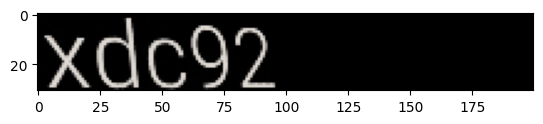

In [15]:
# See what the first validation image for recognition training looks like.
image, text = next(recognition_image_generators[1])
print('This image contains:', text)
plt.imshow(image)

In [16]:
recognition_batch_size = 8
recognizer_basepath = os.path.join(data_dir, f'recognizer_{datetime.datetime.now().isoformat()}')
recognition_train_generator, recognition_val_generator, recognition_test_generator = [
    recognizer.get_batch_generator(
    image_generator=image_generator,
    batch_size=recognition_batch_size,
    lowercase=False
    ) for image_generator in recognition_image_generators
]

In [17]:
recognizer.training_model.fit(
    recognition_train_generator,
    epochs=1,
    steps_per_epoch=math.ceil(len(background_splits[0]) / recognition_batch_size),
    callbacks=[
        tf.keras.callbacks.EarlyStopping(restore_best_weights=True, patience=25),
        tf.keras.callbacks.CSVLogger(f'{recognizer_basepath}.csv', append=True),
        tf.keras.callbacks.ModelCheckpoint(filepath=f'{recognizer_basepath}.h5')
    ],
    validation_data=recognition_val_generator,
    validation_steps=math.ceil(len(background_splits[1]) / recognition_batch_size),
    workers=0,
    # batch_size=recognition_batch_size
)

2025-03-19 15:22:27.445326: W tensorflow/c/c_api.cc:304] Operation '{name:'bn_7/AssignMovingAvg_1/AssignSubVariableOp' id:320 op device:{requested: '', assigned: ''} def:{{{node bn_7/AssignMovingAvg_1/AssignSubVariableOp}} = AssignSubVariableOp[_class=["loc:@bn_7/moving_variance"], _has_manual_control_dependencies=true, dtype=DT_FLOAT](bn_7/moving_variance, bn_7/AssignMovingAvg_1/mul)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2025-03-19 15:22:27.576154: W tensorflow/c/c_api.cc:304] Operation '{name:'training/RMSprop/fc_12/bias/rms/Assign' id:3430 op device:{requested: '', assigned: ''} def:{{{node training/RMSprop/fc_12/bias/rms/Assign}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false](training/RMSprop/fc_12/bias/rms, training/RMSprop/fc_12/bias/rms/Initializer/zeros)}}' 

105/105 [==============================] - ETA: 0s - batch: 52.0000 - size: 8.0000 - loss: 13.3404

/home/linkedata/anaconda3/envs/ocr/lib/python3.10/site-packages/keras/src/engine/training_v1.py:2335: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates = self.state_updates
2025-03-19 15:22:50.176602: W tensorflow/c/c_api.cc:304] Operation '{name:'loss/mul' id:2316 op device:{requested: '', assigned: ''} def:{{{node loss/mul}} = Mul[T=DT_FLOAT, _has_manual_control_dependencies=true](loss/mul/x, loss/lambda_3_loss/value)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
/home/linkedata/anaconda3/envs/ocr/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead

105/105 [==============================] - 26s 230ms/step - batch: 52.0000 - size: 8.0000 - loss: 13.3404 - val_loss: 8.6656


In [ ]:
## Use the models for inference
pipeline = keras_ocr.pipeline.Pipeline(detector=detector, recognizer=recognizer)
image, lines = next(image_generators[0])
predictions = pipeline.recognize(images=[image])[0]
drawn = keras_ocr.tools.drawBoxes(
    image=image, boxes=predictions, boxes_format='predictions'
)
print(
    'Actual:', '\n'.join([' '.join([character for _, character in line]) for line in lines]),
    'Predicted:', [text for text, box in predictions]
)
plt.imshow(drawn)